 ================================
 
 VoltRide demand forecasting (zone-wise) with XGBoost
 ----------------------------------------------------------
 Goal:
   Predict daily ride demand (ride_requests) for each (City, Pickup_Zone)
   and forecast the next 7 days zone-wise.

 Key points:
   - Target is built as: count of Ride_ID per (City, Pickup_Zone, date)
   - Features: calendar + lags [1,2,3,7,14] + rolling mean (3-day) feature
   - Holdout test: last 14 days per zone
   - TimeSeriesSplit CV (walk-forward) + RandomizedSearch for strong regularization
   - Outputs: best_params, metrics_table, zonewise_wide_next7
==========================================================


In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer



 1) Settings

In [26]:
FILE_PATH = "DecodeX_VoltRide_Dataset.xlsx"
SHEET_NAME = "Ride_Level_Data"

TARGET = "ride_requests"

TEST_DAYS = 14          # last N days per zone used as holdout test
FORECAST_DAYS = 7       # next N days to predict

# time-series features
LAGS = [1, 2, 3, 7, 14]
ROLL_W = 4             # <-- rolling mean feature window (rollmean4)

# CV + tuning
N_SPLITS_CV = 4         # requested by you; walk-forward folds
N_ITER = 35
RANDOM_STATE = 42

# plotting (just smoothing for nicer charts)
PLOT_SMOOTH = 7



2) Utility helpers

In [27]:
TRUE_SET = {"yes", "y", "true", "t", "1", "available", "on"}
FALSE_SET = {"no", "n", "false", "f", "0", "unavailable", "off"}

def to_binary(series: pd.Series) -> pd.Series:
    """Turns Yes/No style columns into 1/0 safely."""
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce").clip(0, 1)

    x = series.astype(str).str.strip().str.lower()
    out = pd.Series(np.nan, index=series.index, dtype="float64")

    out[x.isin(TRUE_SET)] = 1.0
    out[x.isin(FALSE_SET)] = 0.0

    # if values are already numeric-like strings, keep them
    num = pd.to_numeric(x, errors="coerce")
    out = out.fillna(num.clip(0, 1))
    return out

def add_calendar_cols(df: pd.DataFrame) -> pd.DataFrame:
    df["dow"] = df["date"].dt.dayofweek
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    return df

def safe_mape(y_true, y_pred):
    """MAPE that won't blow up when y_true is 0."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < 1e-9, np.nan, np.abs(y_true))
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100


3) Load the raw data

In [28]:
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

needed = ["Date", "Ride_ID", "City", "Pickup_Zone"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
if df["Date"].isna().any():
    raise ValueError("Some Date values couldn't be parsed. Please check the 'Date' column.")

df["date"] = df["Date"].dt.floor("D")

# Optional messy Yes/No columns (these are the ones that caused errors earlier)
if "Driver_Available" in df.columns:
    df["Driver_Available_bin"] = to_binary(df["Driver_Available"])

if "Charging_Station_Nearby" in df.columns:
    df["Charging_Station_Nearby_bin"] = to_binary(df["Charging_Station_Nearby"])


4) Aggregate to daily zone demand

In [29]:
group_keys = ["City", "Pickup_Zone", "date"]
agg = {TARGET: ("Ride_ID", "count")}  # <-- target creation

# Add extra columns only if they exist
if "Surge_Multiplier" in df.columns:
    df["Surge_Multiplier_num"] = pd.to_numeric(df["Surge_Multiplier"], errors="coerce")
    agg["avg_surge"] = ("Surge_Multiplier_num", "mean")

if "EV_Battery_%" in df.columns:
    df["EV_Battery_num"] = pd.to_numeric(df["EV_Battery_%"], errors="coerce")
    agg["avg_battery"] = ("EV_Battery_num", "mean")
    agg["min_battery"] = ("EV_Battery_num", "min")

if "Weather" in df.columns:
    agg["weather_mode"] = ("Weather", lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan)

if "Driver_Available_bin" in df.columns:
    agg["driver_avail_rate"] = ("Driver_Available_bin", "mean")

if "Charging_Station_Nearby_bin" in df.columns:
    agg["charging_nearby_rate"] = ("Charging_Station_Nearby_bin", "mean")

daily = df.groupby(group_keys).agg(**agg).reset_index()
daily = add_calendar_cols(daily)
daily = daily.sort_values(["City", "Pickup_Zone", "date"]).reset_index(drop=True)

# We'll use this later for recursive forecasting
daily_history = daily.copy()


5) Holdout split (last TEST_DAYS per zone)

In [30]:
daily["rank_from_end"] = daily.groupby(["City", "Pickup_Zone"])["date"].rank(method="first", ascending=False)
daily["is_test"] = daily["rank_from_end"] <= TEST_DAYS

train_base = daily[~daily["is_test"]].copy().reset_index(drop=True)
test_base  = daily[daily["is_test"]].copy().reset_index(drop=True)

test_keys = set(zip(test_base["City"], test_base["Pickup_Zone"], test_base["date"]))


6) Build features: lags + rollmean3

In [31]:
all_df = pd.concat([train_base, test_base], ignore_index=True)
all_df = all_df.sort_values(["City", "Pickup_Zone", "date"]).reset_index(drop=True)

g = all_df.groupby(["City", "Pickup_Zone"], sort=False)

for lag in LAGS:
    all_df[f"{TARGET}_lag{lag}"] = g[TARGET].shift(lag)

all_df[f"{TARGET}_rollmean{ROLL_W}"] = g[TARGET].shift(1).rolling(ROLL_W).mean()

# drop rows where lag history doesn't exist
lag_cols = [f"{TARGET}_lag{lag}" for lag in LAGS]
all_df = all_df.dropna(subset=lag_cols).reset_index(drop=True)

# rebuild train/test membership after dropping rows
all_df["is_test2"] = list(zip(all_df["City"], all_df["Pickup_Zone"], all_df["date"]))
all_df["is_test2"] = all_df["is_test2"].apply(lambda k: k in test_keys)

train_df = all_df[~all_df["is_test2"]].copy()
test_df  = all_df[all_df["is_test2"]].copy()


7) One-hot encode categoricals

In [32]:
cat_cols = [c for c in ["City", "Pickup_Zone", "weather_mode"] if c in train_df.columns]

train_enc = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_enc  = pd.get_dummies(test_df,  columns=cat_cols, drop_first=True)

# Make sure test has the exact same columns
test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

drop_cols = {TARGET, "date", "rank_from_end", "is_test", "is_test2"}
feature_cols = [c for c in train_enc.columns if c not in drop_cols]

X_train = train_enc[feature_cols]
y_train = train_enc[TARGET]
X_test  = test_enc[feature_cols]
y_test  = test_enc[TARGET]



8) CV (walk-forward) + hyperparameter tuning with strong regularization

In [33]:
base_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

# "Strong regularization" search space (small data friendly)
param_dist = {
    "n_estimators": [300, 600, 900, 1200],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [5, 10, 20, 30],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "reg_alpha": [0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [2.0, 5.0, 10.0, 20.0],
    "gamma": [0.0, 0.2, 0.5, 1.0]
}

tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)  # <-- walk-forward CV
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring=mae_scorer,
    cv=tscv,
    random_state=RANDOM_STATE,
    verbose=0
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
best_params = search.best_params_


9) Holdout evaluation (real test)

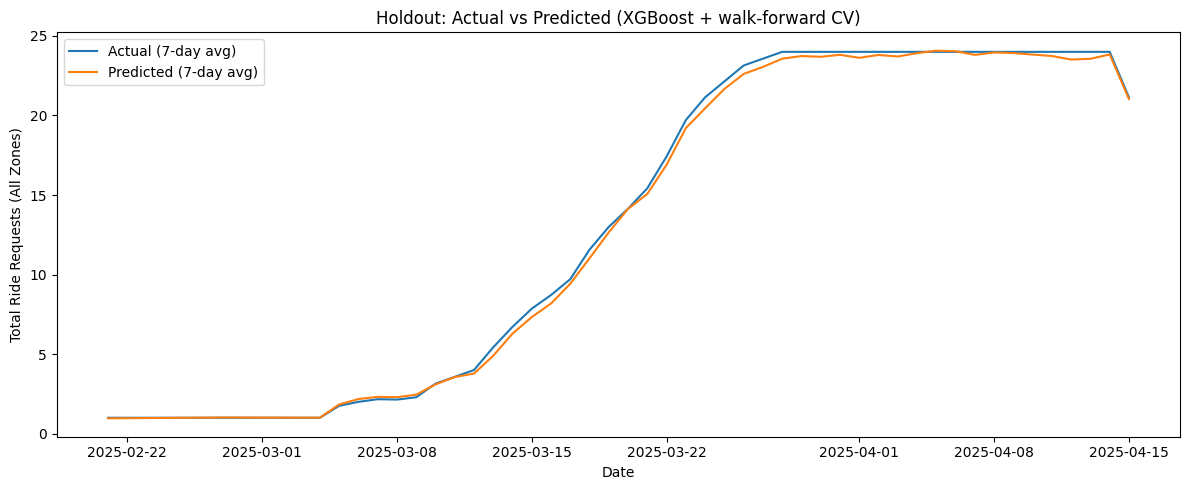

In [34]:
y_pred = best_model.predict(X_test)

mae_val  = mean_absolute_error(y_test, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
mape_val = safe_mape(y_test, y_pred)
r2_val   = r2_score(y_test, y_pred)

# "accuracy-like" (not standard regression, but you asked for accuracy)
acc_like = 1 - (mae_val / (np.mean(y_test) + 1e-9))

metrics_table = pd.DataFrame([{
    "rollmean_feature_window": ROLL_W,
    "LAGS": str(LAGS),
    "CV best score (neg MAE)": float(search.best_score_),
    "MAE (holdout)": float(mae_val),
    "RMSE (holdout)": float(rmse_val),
    "MAPE % (holdout)": float(mape_val),
    "R2 (holdout)": float(r2_val),
    "Accuracy_like (1 - MAE/mean_y)": float(acc_like),
    "n_features": int(X_train.shape[1])
}])


# nice holdout plot (smoothed for readability)
pred_out = test_df[["City", "Pickup_Zone", "date"]].copy().reset_index(drop=True)
pred_out["y_true"] = y_test.values
pred_out["y_pred"] = y_pred

hold_plot = pred_out.groupby("date", as_index=False).agg(y_true=("y_true","sum"), y_pred=("y_pred","sum"))
hold_plot["y_true_smooth"] = hold_plot["y_true"].rolling(PLOT_SMOOTH, min_periods=1).mean()
hold_plot["y_pred_smooth"] = hold_plot["y_pred"].rolling(PLOT_SMOOTH, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(hold_plot["date"], hold_plot["y_true_smooth"], label=f"Actual ({PLOT_SMOOTH}-day avg)")
plt.plot(hold_plot["date"], hold_plot["y_pred_smooth"], label=f"Predicted ({PLOT_SMOOTH}-day avg)")
plt.title("Holdout: Actual vs Predicted (XGBoost + walk-forward CV)")
plt.xlabel("Date")
plt.ylabel("Total Ride Requests (All Zones)")
plt.legend()
plt.tight_layout()
plt.show()

10) Forecast next 7 days (zone-wise), recursive

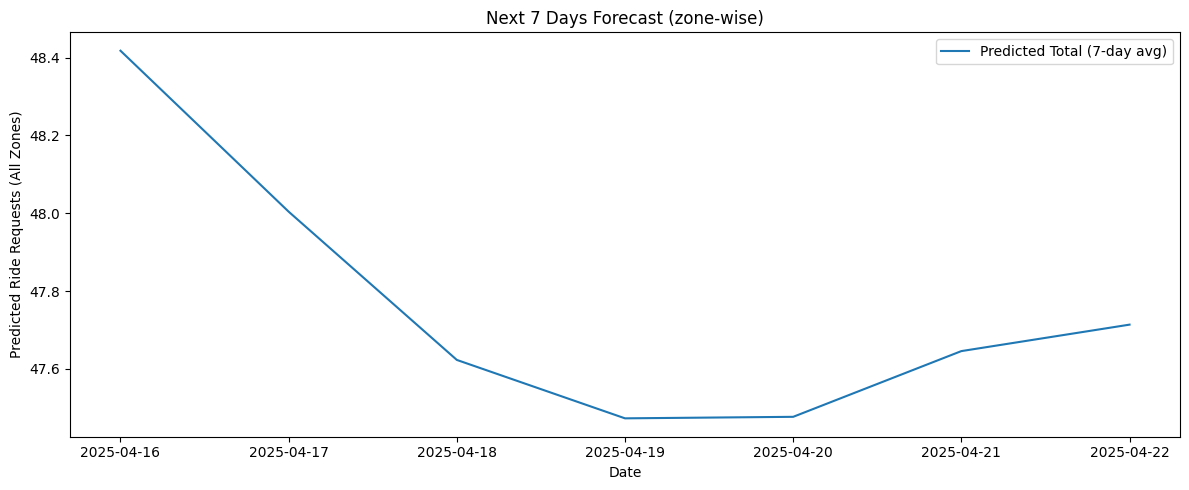

({'subsample': 0.6,
  'reg_lambda': 5.0,
  'reg_alpha': 0.5,
  'n_estimators': 300,
  'min_child_weight': 5,
  'max_depth': 5,
  'learning_rate': 0.03,
  'gamma': 0.0,
  'colsample_bytree': 0.9},
    rollmean_feature_window              LAGS  CV best score (neg MAE)  \
 0                        4  [1, 2, 3, 7, 14]                -0.181493   
 
    MAE (holdout)  RMSE (holdout)  MAPE % (holdout)  R2 (holdout)  \
 0       0.145711        0.272614          8.744651       0.80076   
 
    Accuracy_like (1 - MAE/mean_y)  n_features  
 0                        0.890911          29  ,
          City  Pickup_Zone  2025-04-16  2025-04-17  2025-04-18  2025-04-19  \
 0   Bengaluru            1    1.074958    1.091667    1.070442    1.076444   
 1   Bengaluru            2    1.643634    1.593504    1.478042    1.507515   
 2   Bengaluru            3    2.186394    2.095253    2.012891    2.043824   
 3   Bengaluru            4    0.990171    0.990277    0.988963    0.991022   
 4   Bengaluru      

In [35]:
if hasattr(best_model, "feature_names_in_"):
    expected_features = list(best_model.feature_names_in_)
else:
    booster = best_model.get_booster()
    expected_features = list(booster.feature_names) if booster.feature_names else feature_cols

hist = daily_history.sort_values(["City", "Pickup_Zone", "date"]).reset_index(drop=True)
zones = hist[["City", "Pickup_Zone"]].drop_duplicates().reset_index(drop=True)

# columns to carry forward (simple assumption)
carry_cols = [c for c in ["avg_surge", "avg_battery", "min_battery",
                          "driver_avail_rate", "charging_nearby_rate", "weather_mode"]
              if c in hist.columns]

last_date = hist["date"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq="D")

def build_future_row(zone_hist: pd.DataFrame, city: str, zone: str, d: pd.Timestamp) -> pd.DataFrame:
    row = {"City": city, "Pickup_Zone": zone, "date": d}
    for c in carry_cols:
        row[c] = zone_hist.iloc[-1][c]

    out = pd.DataFrame([row])
    out = add_calendar_cols(out)

    for lag in LAGS:
        out[f"{TARGET}_lag{lag}"] = zone_hist[TARGET].iloc[-lag] if len(zone_hist) >= lag else np.nan

    out[f"{TARGET}_rollmean{ROLL_W}"] = (
        zone_hist[TARGET].iloc[-ROLL_W:].mean() if len(zone_hist) >= ROLL_W else np.nan
    )
    return out

def encode_future_row(raw: pd.DataFrame) -> pd.DataFrame:
    cats = [c for c in ["City", "Pickup_Zone", "weather_mode"] if c in raw.columns]
    enc = pd.get_dummies(raw, columns=cats, drop_first=True)
    return enc.reindex(columns=expected_features, fill_value=0)

future_rows = []

for _, z in zones.iterrows():
    city, zone = z["City"], z["Pickup_Zone"]

    zone_hist = hist[(hist["City"] == city) & (hist["Pickup_Zone"] == zone)].copy()
    zone_hist = zone_hist.sort_values("date").reset_index(drop=True)

    if len(zone_hist) < max(LAGS):
        continue

    for d in future_dates:
        raw = build_future_row(zone_hist, city, zone, d)
        X_next = encode_future_row(raw)

        y_next = float(best_model.predict(X_next)[0])
        future_rows.append({"City": city, "Pickup_Zone": zone, "date": d, "y_pred": y_next})

        # Append prediction for recursion
        new_point = {"City": city, "Pickup_Zone": zone, "date": d, TARGET: y_next}
        for c in carry_cols:
            new_point[c] = raw[c].iloc[0]
        zone_hist = pd.concat([zone_hist, pd.DataFrame([new_point])], ignore_index=True)

next_week_pred = pd.DataFrame(future_rows).sort_values(["City", "Pickup_Zone", "date"]).reset_index(drop=True)

# Make a wide table (one row per zone, dates as columns)
zonewise_wide_next7 = next_week_pred.pivot_table(
    index=["City", "Pickup_Zone"],
    columns="date",
    values="y_pred",
    aggfunc="mean"
).reset_index()

zonewise_wide_next7.columns = [
    c.strftime("%Y-%m-%d") if isinstance(c, pd.Timestamp) else c
    for c in zonewise_wide_next7.columns
]

# Optional: total forecast plot
next_plot = next_week_pred.groupby("date", as_index=False).agg(total_pred=("y_pred", "sum"))
next_plot["total_pred_smooth"] = next_plot["total_pred"].rolling(PLOT_SMOOTH, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(next_plot["date"], next_plot["total_pred_smooth"], label=f"Predicted Total ({PLOT_SMOOTH}-day avg)")
plt.title("Next 7 Days Forecast (zone-wise)")
plt.xlabel("Date")
plt.ylabel("Predicted Ride Requests (All Zones)")
plt.legend()
plt.tight_layout()
plt.show()

# LAST LINE OUTPUT (as a single return)
best_params, metrics_table, zonewise_wide_next7